# Analaysis of deep learning models segmentation performance for rescaled images
This notebook allows to compare the results obtained for segmentation and the ground truth across image resolutions. The notebook will compute the following metrics and provide plots to visualise the results: 
- Mean Intersection-over-Union (IoU) as described in the Cell Tracking Challenge (True positives identified with a minimum of 50% overlap).
- Object diameter
- Theoretical throughput

**Expected output**:
- A new folder (`Results`) in the main directory with `.csv`files containing the numerical data for the assessment.
- Images of true positives, false positives, and false negatives for each image.



## 1. Import dependencies

In [1]:
from rescale4dl import analyse
from rescale4dl.plot import generate_binary_semantic_box_plot, generate_semantic_gt_pred_bar_plot,\
generate_instance_box_plot, generate_instance_gt_pred_bar_plot, generate_instance_wt_treatment_bar_plot, plot_segmentation_example, plot_data_distributions
from rescale4dl import stats
import shutil
import os

Matplotlib is building the font cache; this may take a moment.


## 2. Compile quantitative data
This cell will compute analytical measurements for all the datasets and rescaling factors contained in the given INPUT_DIR.
-  **INPUT_DIR**  
   - Path to the folder containing the DATASET folder with input images and the annotations, stored as `.tiff`files.
   - The input directory is expected to contain the following folders and structure (preserving the naming for "GT" and "Prediction" folders). See the structure for the 2D case in "ReScale4DL/Examples/segmentation_results".
        - **DATASET (e.g., Saureus_instance_segmentation)**
            * **OG**
                * GT
                    - images.tiff
                * Prediction
                    - images.tiff
            * **downsampling_2**
                * GT
                    - images.tiff
                * Prediction
                    - images.tiff
 
   - Example: `ReScale4DL/Examples/segmentation_results`

In [ ]:
# Directory with folders of sampling folders with GT and Prediction folder pairs inside
INPUT_DIR = "/Users/esti/Documents/PROYECTOS/DOWNSAMPLING/ReScale4DL/Examples/segmentation_results/" # Add your own path to the directory with the sampling folders

# List of sampling folders to be included in the analysis. If None, all folders in the datasets of the input directory will be included.
# sampling_dir_list = [
#         "upsampling_16",
#         "upsampling_8",
#         "upsampling_4",
#         "upsampling_2",
#         "OG",
#         "downsampling_2",
#         "downsampling_4",
#         "downsampling_8",
#         "downsampling_16",
#     ]
# Calculate object properties statistics
analyse(INPUT_DIR, sampling_dir_list=None)

Calculating properties for Deepbacs_Semantic_Segmentation
Sampling folders to analyze: ['upsampling_2', 'OG', 'downsampling_2']
Reading file: /Users/esti/Documents/PROYECTOS/DOWNSAMPLING/ReScale4DL/Examples/segmentation_results/Deepbacs_Semantic_Segmentation/OG/GT/pos2_fr_1.tif
pos2_fr_1.tif from OG has 2 objects in GT and 2 objects in Prediction
Elapsed time: 00:00:00
Reading file: /Users/esti/Documents/PROYECTOS/DOWNSAMPLING/ReScale4DL/Examples/segmentation_results/Deepbacs_Semantic_Segmentation/OG/GT/pos5_fr_1.tif
pos5_fr_1.tif from OG has 2 objects in GT and 2 objects in Prediction
Elapsed time: 00:00:00
Reading file: /Users/esti/Documents/PROYECTOS/DOWNSAMPLING/ReScale4DL/Examples/segmentation_results/Deepbacs_Semantic_Segmentation/OG/GT/pos7_fr_1.tif
pos7_fr_1.tif from OG has 2 objects in GT and 2 objects in Prediction
Elapsed time: 00:00:00
Reading file: /Users/esti/Documents/PROYECTOS/DOWNSAMPLING/ReScale4DL/Examples/segmentation_results/Deepbacs_Semantic_Segmentation/OG/GT/pos

### 2.1 Display some of the example results
Display an example ground truth labelling, the prediction and the difference between them. Expected input parameters:
1. **INPUT_DIR**
   - Same as in the previous cell (e.g., `INPUT_DIR="ReScale4DL/Examples/segmentation_results"`)
2. **DATASET**  
   - Name of the dataset to display (e.g., `DATASET = "Saureus_instance_segmentation"`)
3. **SCALING**
   - Name of the folder corresponding to the scaling example to display (e.g., `SCALING = "downsampling_4"`)

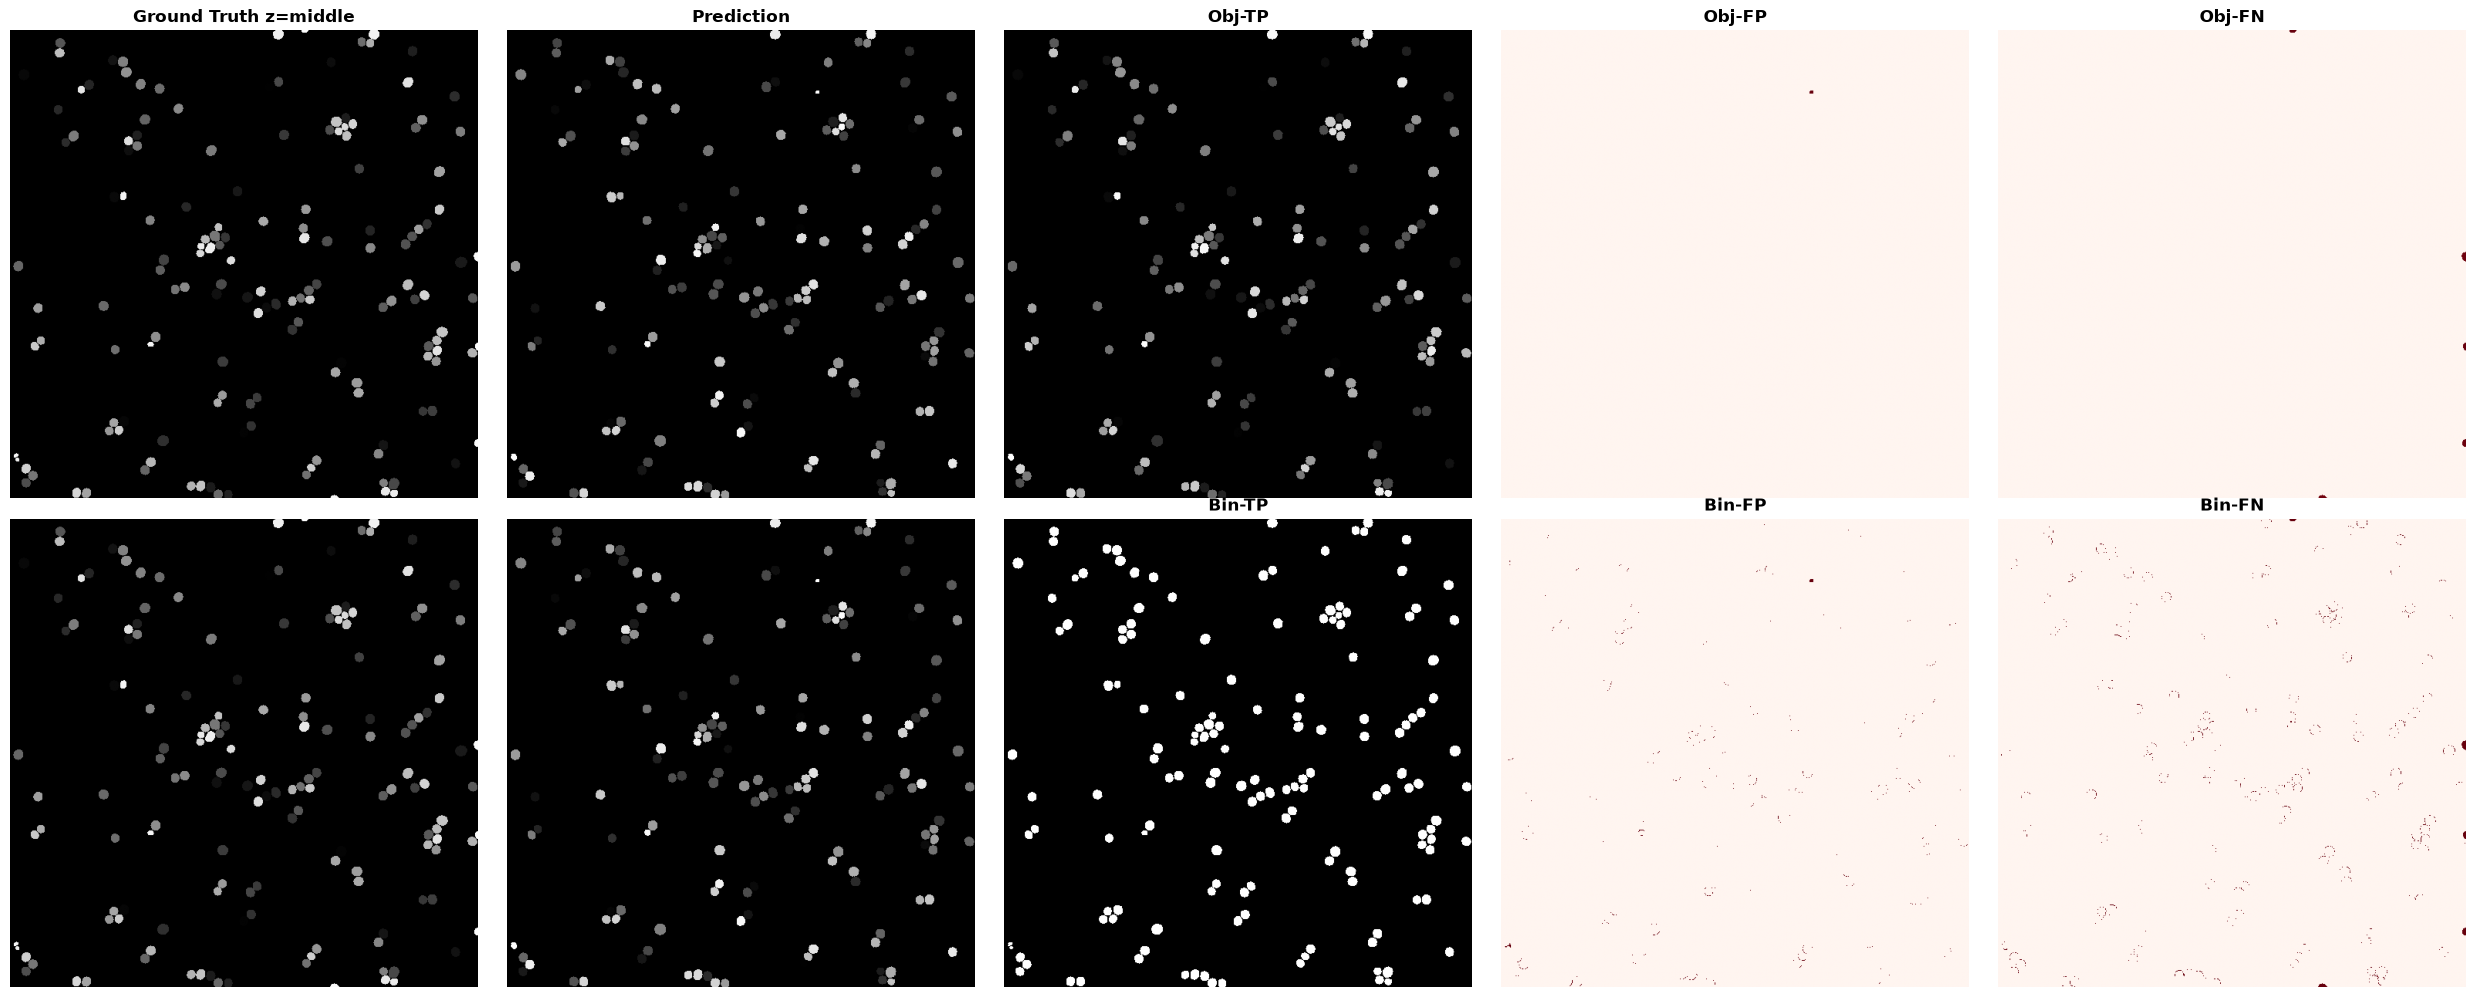

In [ ]:
INPUT_DIR = "/Users/esti/Documents/PROYECTOS/DOWNSAMPLING/ReScale4DL/Examples/segmentation_results" # Add your own path to the directory with the sampling folders
DATASET = "Saureus_instance_segmentation" 
SCALING = "downsampling_4" 

# Usage (same as before):
plot_segmentation_example(
    input_dir=INPUT_DIR,
    dataset=DATASET,
    scaling=SCALING,
    slice_axis=0,
)

## 3. Plot analytical results

### 3.1 Semantic segmentation
Example dataset: "Deepbacs_Semantic_Segmentation" (The example in this section expects section 2 to have been executed with the example data)


**Expected parameters**
1. **ANALYSIS_DIR**
   - Main directory where the DATASET folder stores all the csv files for morphology
2. **DATASET**
   - Name of the dataset, which also corresponds with its folder name, e.g., `DATASET = "Deepbacs_Semantic_Segmentation"`
3. **IMAGE_SIZES**
   - Path to the csv file containing basic information about the dataset. For the example data in the `segmentation_results` folder, the csv file can be found at `segmentation_results/DATASET/DATASET_dataset_info.csv`. For the paper results in the `analysis_results`, the csv file can be found at `analysis_results/dataset_info.csv`
4. **ORIGINAL_DATASET_FOLDERNAME**
   - The name of the folder in DATASET that corresponds to the original data. `"OG"` for the example data in `segmentation_results`; `"og"` for the example data in `"analysis_results"`.
5. **OUTPUT_DIR**
   - A directory to save the plots.
  
**Expected plots**
- IoU and Theoretical Throughput accross scales
- Barplot with diameter distributions for the ground truth and the segmentation results

In [ ]:
ANALYSIS_DIR = "/Users/esti/Documents/PROYECTOS/DOWNSAMPLING/ReScale4DL/Examples/segmentation_results" # Add your own path to the directory with the sampling folders
DATASET = "Deepbacs_Semantic_Segmentation"
ORIGINAL_DATASET_FOLDERNAME = "OG" 
IMAGE_SIZES = os.path.join(ANALYSIS_DIR, DATASET, f"{DATASET}_dataset_info.csv")
OUTPUT_DIR = os.path.join(ANALYSIS_DIR, DATASET, "Results", "plots")

**Run**

DONE!
DONE!
DONE!


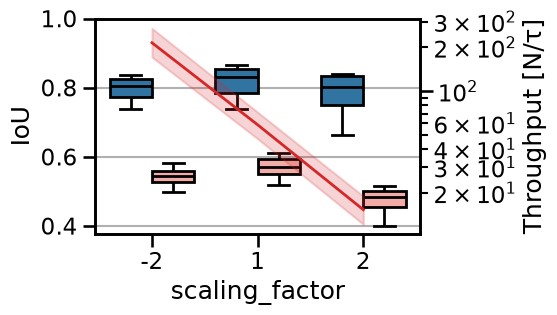

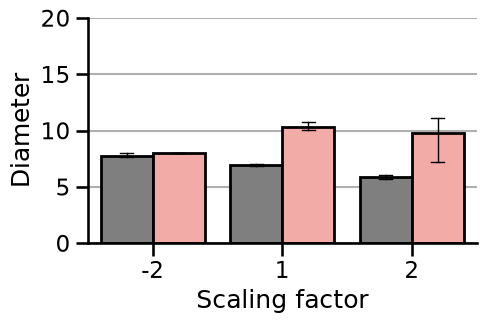

In [17]:
## Run
dataset_name_match_dict = {DATASET: DATASET}
fig_name = f"IoU for {DATASET}"
y_axis = "IoU"
os.makedirs(OUTPUT_DIR, exist_ok=True)


## Boxplot of accuracy metrics
generate_binary_semantic_box_plot(ANALYSIS_DIR,
                                  DATASET,
                                DATASET,
                                fig_name, 
                                y_axis, 
                                thoughput_plot=True, 
                                y_axis_2 = "Obj_per_FOV_mean"
                                 )

## Barplot of the diameter
fig_name = f"Diameter barplot for {DATASET}"
generate_semantic_gt_pred_bar_plot(ANALYSIS_DIR, 
                           DATASET, 
                           fig_name,
                           output_path=OUTPUT_DIR)

### 3.2 Instance segmentation
Example dataset = "Saureus_instance_segmentation" and "Saureus_instance_segmentation_pc190723"

**Expected parameters**
1. **ANALYSIS_DIR**
   - Main directory where the DATASET folder stores all the csv files for morphology
2. **DATASET**
   - Name of the dataset, which also corresponds with its folder name, e.g., `DATASET = "Saureus_instance_segmentation"`
3. **IMAGE_SIZES**
   - Path to the csv file containing basic information about the dataset. For the example data in the `segmentation_results` folder, the csv file can be found at `segmentation_results/DATASET/DATASET_dataset_info.csv`. For the paper results in the `analysis_results`, the csv file can be found at `analysis_results/dataset_info.csv`
4. **ORIGINAL_DATASET_FOLDERNAME**
   - The name of the folder in DATASET that corresponds to the original data. `"OG"` for the example data in `segmentation_results`; `"og"` for the example data in `"analysis_results"`.
5. **OUTPUT_DIR**
   - A directory to save the plots.

In [ ]:
ANALYSIS_DIR = "/Users/esti/Documents/PROYECTOS/DOWNSAMPLING/ReScale4DL/Examples/segmentation_results" # Add your own path to the directory with the sampling folders
DATASET = "Saureus_instance_segmentation"
ORIGINAL_DATASET_FOLDERNAME = "OG" 
OUTPUT_DIR = os.path.join(ANALYSIS_DIR, DATASET, "Results", "plots")

DONE!
DONE!
DONE!


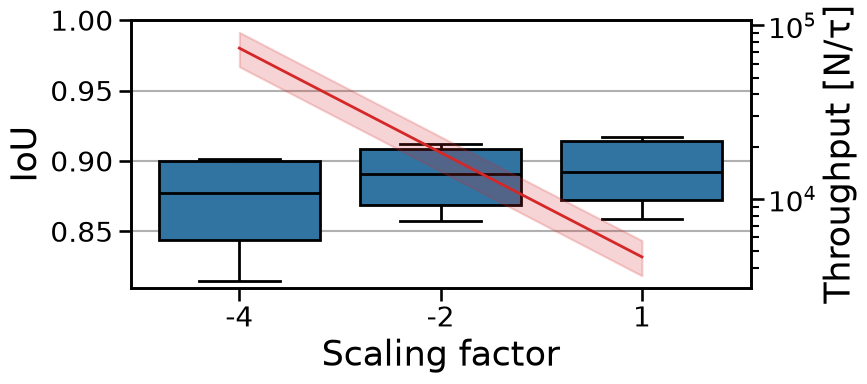

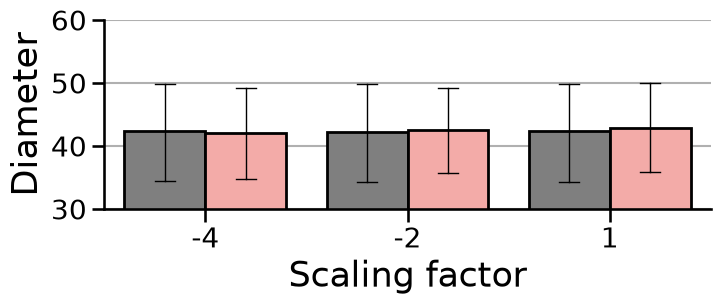

In [19]:
##
dataset_name_match_dict = {DATASET: DATASET}
fig_name = f"IoU for {DATASET}"
y_axis = "IoU"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Boxplot of accuracy metrics
generate_instance_box_plot(ANALYSIS_DIR, 
                           DATASET, 
                           fig_name, 
                           y_axis, 
                           thoughput_plot=True, 
                           original_folder_name = ORIGINAL_DATASET_FOLDERNAME,
                           y_axis_2 = "Obj_per_FOV_mean",
                           output_path=OUTPUT_DIR
                           )
## Barplot of the diameter
fig_name = f"Diameter distribution {DATASET}"
generate_instance_gt_pred_bar_plot(ANALYSIS_DIR, 
                           DATASET, 
                           fig_name,
                           output_path=OUTPUT_DIR)

## 4. Reproduce the plots from the manuscript (Optional)
We provide the results obtained with the experiments in ReScale4DL publication that can be used to reproduce the original plots in the publication. These are stored in ReScale4DL repository at `Examples/analysis_results`. 

Provide the following parameters on each of the examples: 
1. **DATASET**
    - One of the following ones:
        - `"Saureus_instance_segmentation", "Deepbacs_Instance_Segmentation", "Deepbacs_Semantic_Segmentation", "Saureus_instance_segmentation_pc190723", "Saureus_instance_segmentation", "Worm_Semantic_Segmentation"`
3. **ANALYSIS_DIR**
    - The absolute path to `"Examples/analysis_results"`


### 4.1 Semantic Segmentation with DeepBacs

DONE!
DONE!
DONE!


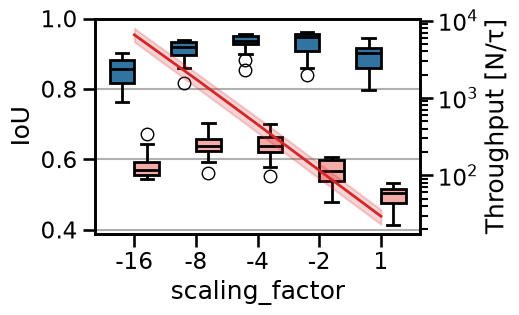

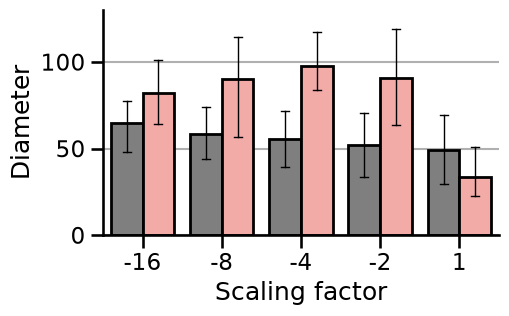

In [ ]:
ANALYSIS_DIR = "/Users/esti/Documents/PROYECTOS/DOWNSAMPLING/ReScale4DL/Examples/analysis_results" # Add your own path to the directory with the sampling folders
DATASET = "Worm_Semantic_Segmentation"

## Unzip the data
filename = os.path.join(ANALYSIS_DIR, f"{DATASET}.zip")
extract_dir = os.path.join(ANALYSIS_DIR)
shutil.unpack_archive(filename, extract_dir)

## Plotting default params
ORIGINAL_DATASET_FOLDERNAME = "OG" 
OUTPUT_DIR = os.path.join(ANALYSIS_DIR, DATASET,"plots")
dataset_name_match_dict = {DATASET: DATASET}
os.makedirs(OUTPUT_DIR, exist_ok=True)

fig_name = f"IoU for {DATASET}"
y_axis = "IoU"

## Boxplot of accuracy metrics
generate_binary_semantic_box_plot(ANALYSIS_DIR,
                                  DATASET,
                                DATASET,
                                fig_name, 
                                y_axis, 
                                thoughput_plot=True, 
                                y_axis_2 = "Obj_per_FOV_mean",
                                original_folder_name = ORIGINAL_DATASET_FOLDERNAME,                               
                                output_path=OUTPUT_DIR, x_axis="scaling_factor", plot_type="boxplot")
## Barplot of the diameter
fig_name = f"Diameter barplot for {DATASET}"
generate_semantic_gt_pred_bar_plot(ANALYSIS_DIR, 
                           DATASET, 
                           fig_name,
                           x_axis="scaling_factor", 
                           output_path=OUTPUT_DIR)

### 4.2 Instance Segmentation with S. aureus

DONE!
DONE!
DONE!


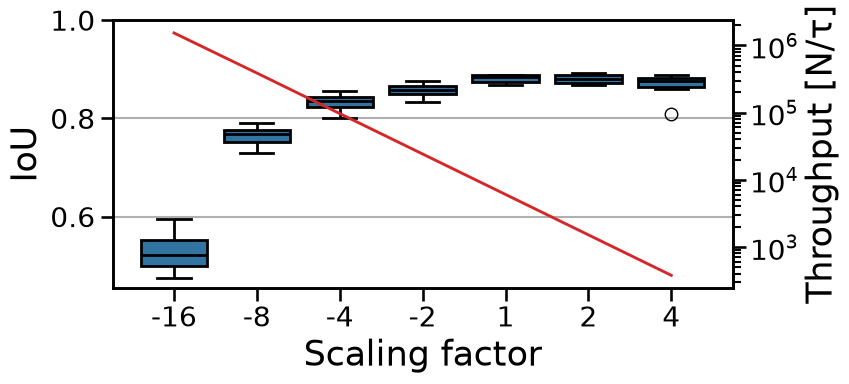

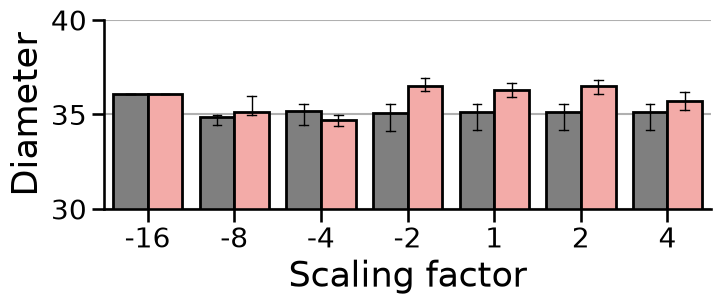

In [ ]:
ANALYSIS_DIR = "/Users/esti/Documents/PROYECTOS/DOWNSAMPLING/ReScale4DL/Examples/analysis_results" # Add your own path to the directory with the sampling folders
DATASET = "Saureus_instance_segmentation"

## Unzip the data
filename = os.path.join(ANALYSIS_DIR, f"{DATASET}.zip")
extract_dir = os.path.join(ANALYSIS_DIR)
shutil.unpack_archive(filename, extract_dir)

## Plotting default params
ORIGINAL_DATASET_FOLDERNAME = "OG" 
OUTPUT_DIR = os.path.join(ANALYSIS_DIR, DATASET,"plots")
dataset_name_match_dict = {DATASET: DATASET}
os.makedirs(OUTPUT_DIR, exist_ok=True)

fig_name = f"IoU for {DATASET}"
y_axis = "IoU"

## Plot boxplot
generate_instance_box_plot(ANALYSIS_DIR, 
                           DATASET, 
                           fig_name, 
                           y_axis, 
                           thoughput_plot=True, 
                           y_axis_2 = "Obj_per_FOV_mean",
                           original_folder_name = ORIGINAL_DATASET_FOLDERNAME,
                           output_path=OUTPUT_DIR,
                           x_axis = "scaling_factor")

## Plot barplot
fig_name = f"Diameter distribution {DATASET}"
generate_instance_gt_pred_bar_plot(ANALYSIS_DIR, 
                           DATASET, 
                           fig_name,
                           output_path=OUTPUT_DIR,
                            x_axis = "scaling_factor")

### 4.3 Diameter comparison for WT and treated S. aureus

DONE!
DONE!
DONE!
DONE!


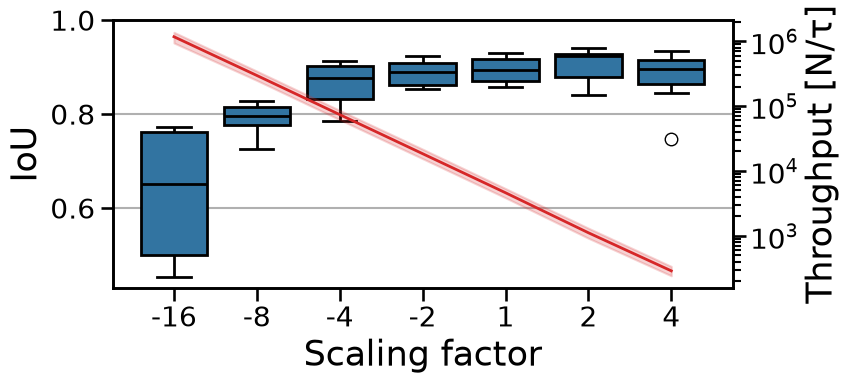

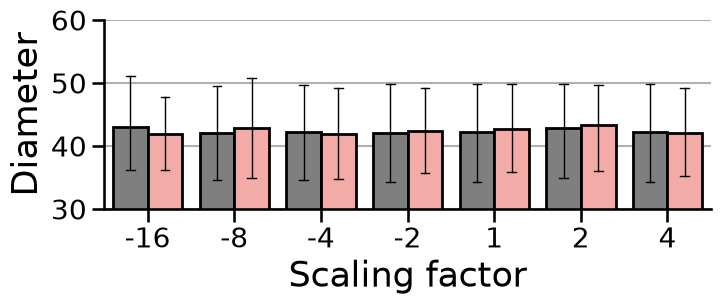

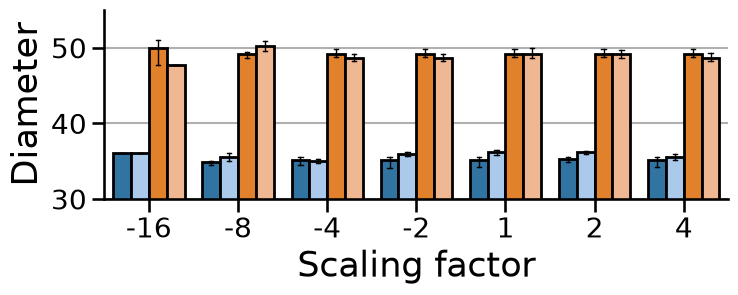

In [ ]:
ANALYSIS_DIR = "/Users/esti/Documents/PROYECTOS/DOWNSAMPLING/ReScale4DL/Examples/analysis_results" # Add your own path to the directory with the sampling folders
DATASET = "Saureus_instance_segmentation_pc190723"

## Unzip the data
filename = os.path.join(ANALYSIS_DIR, f"{DATASET}.zip")
extract_dir = os.path.join(ANALYSIS_DIR)
shutil.unpack_archive(filename, extract_dir)


## Plotting default params
ORIGINAL_DATASET_FOLDERNAME = "OG" 
OUTPUT_DIR = os.path.join(ANALYSIS_DIR, DATASET,"plots")
dataset_name_match_dict = {DATASET: DATASET}
os.makedirs(OUTPUT_DIR, exist_ok=True)

fig_name = f"IoU for {DATASET}"
y_axis = "IoU"

## Plot boxplot
generate_instance_box_plot(ANALYSIS_DIR, 
                           DATASET, 
                           fig_name, 
                           y_axis, 
                           thoughput_plot=True, 
                           y_axis_2 = "Obj_per_FOV_mean",
                           original_folder_name = ORIGINAL_DATASET_FOLDERNAME,
                           output_path=OUTPUT_DIR,
                           x_axis = "scaling_factor")

## Plot barplot
fig_name = f"Diameter distribution {DATASET}"
generate_instance_gt_pred_bar_plot(ANALYSIS_DIR, 
                           DATASET, 
                           fig_name,
                           output_path=OUTPUT_DIR,
                            x_axis = "scaling_factor")

## Barplot for groups
antibiotic_samples = ["1.tif", "11.tif", "12.tif", "13.tif", "14.tif", "8.tif"]
generate_instance_wt_treatment_bar_plot(ANALYSIS_DIR, 
                           DATASET, 
                           fig_name, 
                           antibiotic_samples,
                           output_path=OUTPUT_DIR,
                           x_axis = "scaling_factor")

## 5. Statistical analysis
Calculate basic data distribution values and compare distributions accross different rescaling factors.
These can be calculated with the example data as follows:
1. **DATASET**
    - One of the following ones:
        - `"Saureus_instance_segmentation", "Deepbacs_Instance_Segmentation", "Deepbacs_Semantic_Segmentation", "Saureus_instance_segmentation_pc190723", "Saureus_instance_segmentation", "Worm_Semantic_Segmentation"`
2. **ANALYSIS_DIR**
    - The absolute path to `"Examples/analysis_results"`
3. **QUNATITATIVE_COLUMN**
    - Typically `"IoU"`. However, one can choose to compare other metrics such as `"f1_score", "pred_diameter_median", "pred_area", "Sensitivity", "pred_Circularity", "Accuracy"`. 
4. **CATEGORICAL_COLUMN**
    - List of column names dividing the data in groups for comparison. E.g., `["Grand_Parent_Folder"]`.
5. **TEST_TYPE**
    - `"t-test"`: When both groups are normally distributed and have equal variances.
    - `"Welch's t-test"`: When both groups are normally distributed and have unequal variances.
    - `"Kolmogorov-Smirnov"`: When at least one of the variables is not normally distributed. 
6. **TEST_CHOICE** 
  - `"Automatic"` if you want to run an automatic testing based on assessed properties of the data distribution. 
  - `"Manual"` to manually indicate what test to run.




The statistical test chosen is Kolmogorov-Smirnov


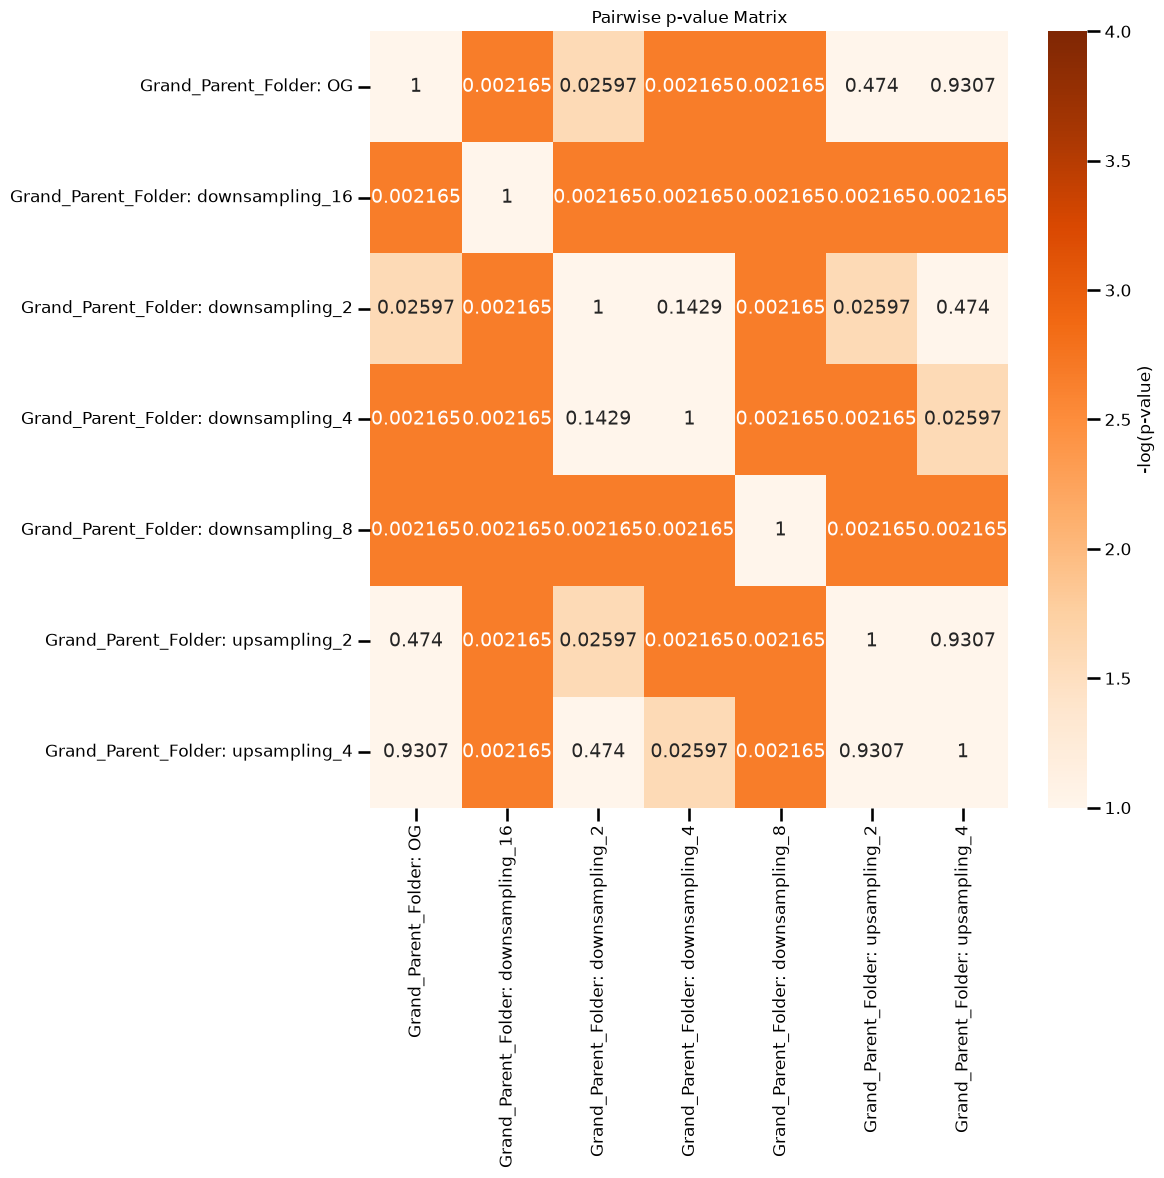

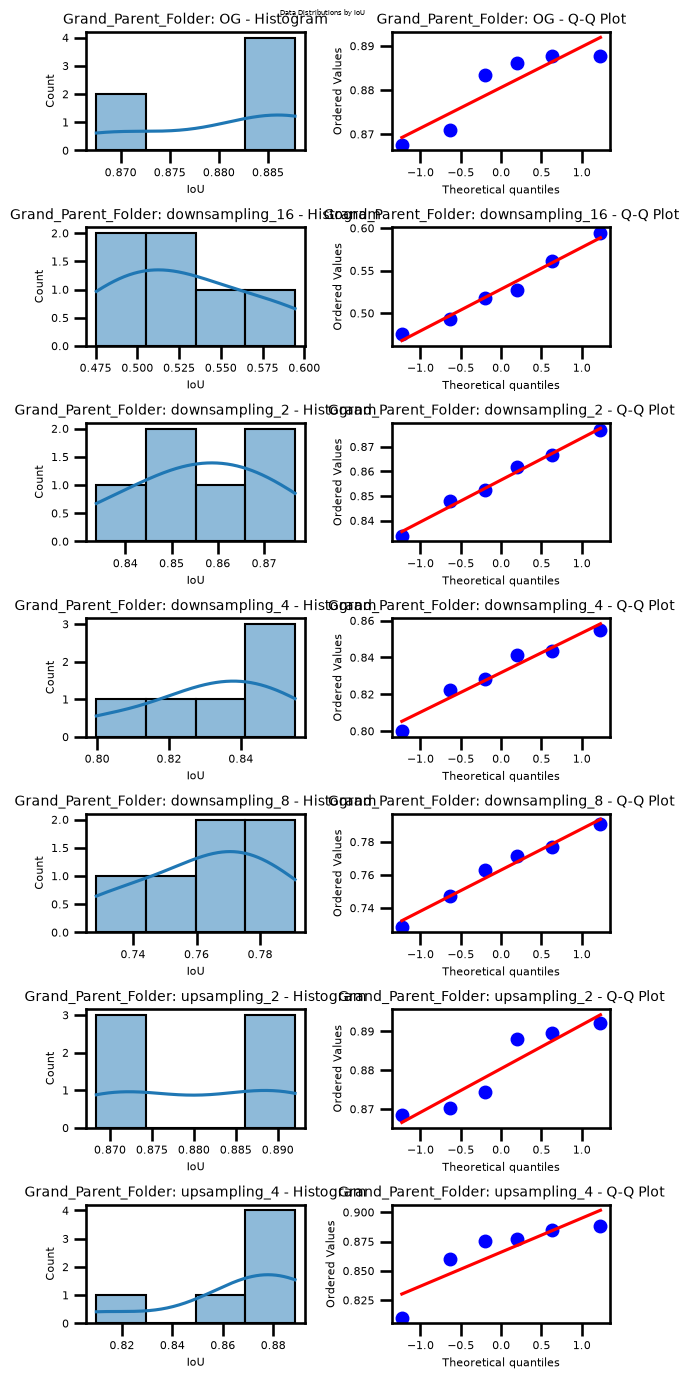

,Hierarchy1,Hierarchy2,N Hierarchy1,N Hierarchy2,Test,Statistic,p-value,Significance
0,Grand_Parent_Folder: OG,Grand_Parent_Folder: downsampling_16,6,6,Kolmogorov-Smirnov,1.000000,0.002165,***
1,Grand_Parent_Folder: OG,Grand_Parent_Folder: downsampling_2,6,6,Kolmogorov-Smirnov,0.833333,0.025974,*
2,Grand_Parent_Folder: OG,Grand_Parent_Folder: downsampling_4,6,6,Kolmogorov-Smirnov,1.000000,0.002165,***
3,Grand_Parent_Folder: OG,Grand_Parent_Folder: downsampling_8,6,6,Kolmogorov-Smirnov,1.000000,0.002165,***
4,Grand_Parent_Folder: OG,Grand_Parent_Folder: upsampling_2,6,6,Kolmogorov-Smirnov,0.500000,0.474026,
5,Grand_Parent_Folder: OG,Grand_Parent_Folder: upsampling_4,6,6,Kolmogorov-Smirnov,0.333333,0.930736,
6,Grand_Parent_Folder: downsampling_16,Grand_Parent_Folder: downsampling_2,6,6,Kolmogorov-Smirnov,1.000000,0.002165,***
7,Grand_Parent_Folder: downsampling_16,Grand_Parent_Folder: downsampling_4,6,6,Kolmogorov-Smirnov,1.000000,0.002165,***
8,Grand_Parent_Folder: downsampling_16,Grand_Parent_Folder: downsampling_8,6,6,Kolmogorov-Smirnov,1.000000,0.002165,***
9,Grand_Parent_Folder: downsampling_16,Grand_Parent_Folder: upsampling_2,6,6,Kolmogorov-Smirnov,1.000000,0.002165,***


In [ ]:
## Input variables for stats
DATASET = "Saureus_instance_segmentation" # "Deepbacs_Semantic_Segmentation" #"Worm_Semantic_Segmentation"
ANALYSIS_DIR = "/Users/esti/Documents/PROYECTOS/DOWNSAMPLING/ReScale4DL/Examples/analysis_results/" # Add your own path to the directory with the sampling folders
QUANTITATIVE_COLUMN = "IoU"
CATEGORICAL_COLUMN = ["Grand_Parent_Folder"]
TEST_TYPE = "Kolmogorov-Smirnov" # "t-test"
TEST_CHOICE = "Manual" # "Manual" 
FILENAME = "summary_stats.csv" # "IoU_per_obj_stats.csv"

# import pandas as pd
# df = pd.read_csv(ANALYSIS_DIR)
# ## Compute basic stats
# print(df.groupby(CATEGORICAL_COLUMN)[QUANTITATIVE_COLUMN].describe())



## Compute statistical tests
results = stats.compute_statistical_analysis(ANALYSIS_DIR,
                                             DATASET,
                                             QUANTITATIVE_COLUMN,
                                             CATEGORICAL_COLUMN,
                                             filename = FILENAME,
                                             test_type=TEST_TYPE,
                                             choose_test=TEST_CHOICE)

plot_data_distributions(ANALYSIS_DIR,
                        DATASET,
                        QUANTITATIVE_COLUMN,
                        CATEGORICAL_COLUMN,
                        filename = FILENAME)
results